### Problem 2: The Shifted and Squeezed Gaussian

**Problem Statement:**
A particle of mass $m$ in a harmonic oscillator potential $V(x)=\frac{1}{2}m\omega^2x^2$ is initially prepared in a Gaussian wave packet given by:
$$\psi(x,0)=Ne^{-\frac{(x-x_0)^2}{a^2}}$$
where $x_0$ is an initial spatial shift, $a$ is the initial width of the wave packet, and $a\neq\sqrt{\hbar/m\omega}$ (which is the natural width of the oscillator ground state).

**Tasks:**
1. Determine the time evolution of the wave packet, $\psi(x,t)$.
2. Calculate the expectation values of position $\langle x\rangle(t)$ and momentum $\langle p\rangle(t)$.
3. Determine the uncertainty in position $\Delta x(t)$ and show how the wave packet width oscillates or "breathes" over time.


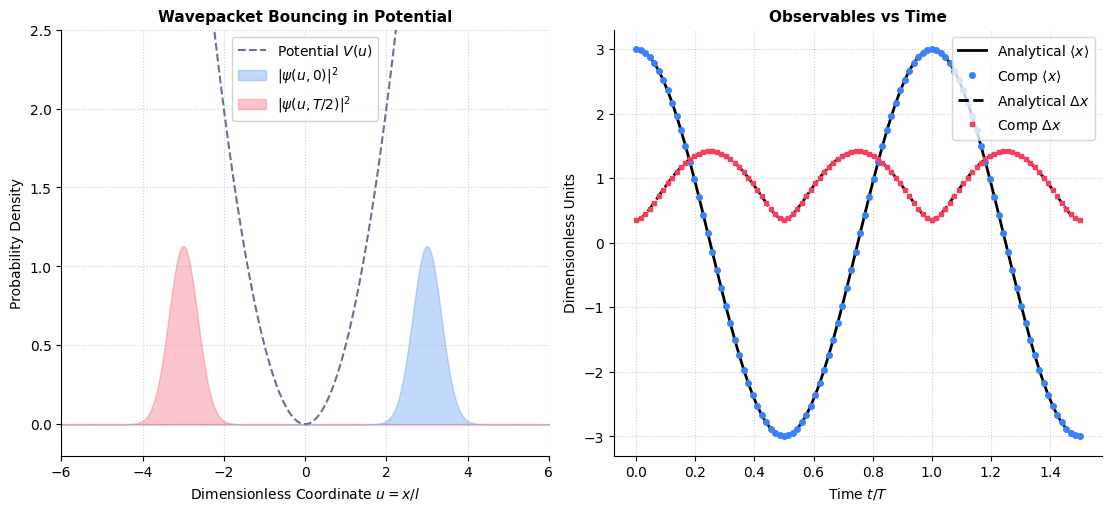

In [ ]:
# --- 1. Physical Parameters ---
x0 = 3.0 * l        # initial shift
a = 0.5 * l         # squeezed width (narrower than ground state)
n_max2 = 40         # number of eigenstates for expansion
T_period = 2 * np.pi / omega

# Initial State
N_g = (np.pi * a**2)**(-0.25)
psi0_g = N_g * np.exp(-0.5 * ((x - x0)/a)**2)

# --- 2. Eigenfunction Coefficients ---
coefficients_g = []
for n in range(n_max2):
    psiN = psi_n(n, x)
    cn = simpson(psiN * psi0_g, x)
    coefficients_g.append(cn)
coefficients_g = np.array(coefficients_g)

# Time Evolution function
def get_psi_t_g(t_val):
    psi_t = np.zeros_like(x, dtype=complex)
    for n in range(n_max2):
        En = (n + 0.5) * hbar * omega
        phase = np.exp(-1j * En * t_val / hbar)
        psi_t += coefficients_g[n] * psi_n(n, x) * phase
    return psi_t

# --- 3. 2-Panel Plotting ---
t_half = T_period / 2.0
psi_half = get_psi_t_g(t_half)

fig2, (ax2_1, ax2_2) = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")

# Panel 1: Wavefunctions and Well
ax2_1.plot(u, V_u, color=plot_colors['potential'], ls='--', lw=1.5, label='Potential $V(u)$')
ax2_1.fill_between(u, (np.abs(psi0_g)*np.sqrt(l))**2, color='#3b82f6', alpha=0.3, label=r'$|\psi(u,0)|^2$')
ax2_1.fill_between(u, (np.abs(psi_half)*np.sqrt(l))**2, color='#f43f5e', alpha=0.3, label=r'$|\psi(u,T/2)|^2$')
ax2_1.set_xlim(-6, 6)
ax2_1.set_ylim(-0.2, 2.5)
ax2_1.set_title("Wavepacket Bouncing in Potential", fontsize=11, fontweight='semibold')
ax2_1.set_xlabel(r"Dimensionless Coordinate $u = x/l$")
ax2_1.set_ylabel("Probability Density")
ax2_1.grid(True, linestyle=':', alpha=0.6)
ax2_1.legend(loc='upper center', framealpha=0.9)
ax2_1.spines['top'].set_visible(False)
ax2_1.spines['right'].set_visible(False)

# Panel 2: Expectation Values over Time
t_array = np.linspace(0, 1.5 * T_period, 100)
x_exp_comp, dx_comp = [], []
for t_val in t_array:
    pt = get_psi_t_g(t_val)
    prob_t = np.abs(pt)**2
    x_exp = simpson(x * prob_t, x)
    x2_exp = simpson(x**2 * prob_t, x)
    x_exp_comp.append(x_exp / l)
    dx_comp.append(np.sqrt(x2_exp - x_exp**2) / l)

# Analytical
x_exp_ana = (x0 / l) * np.cos(omega * t_array)
dx_ana = (a / (np.sqrt(2)*l)) * np.sqrt(np.cos(omega*t_array)**2 + (l/a)**4 * np.sin(omega*t_array)**2)

ax2_2.plot(t_array / T_period, x_exp_ana, 'k-', lw=2, label=r'Analytical $\langle x \rangle$')
ax2_2.plot(t_array / T_period, x_exp_comp, 'o', color='#3b82f6', markersize=4, label=r'Comp $\langle x \rangle$')
ax2_2.plot(t_array / T_period, dx_ana, 'k--', lw=2, label=r'Analytical $\Delta x$')
ax2_2.plot(t_array / T_period, dx_comp, 's', color='#f43f5e', markersize=3, label=r'Comp $\Delta x$')
ax2_2.set_title("Observables vs Time", fontsize=11, fontweight='semibold')
ax2_2.set_xlabel("Time $t/T$")
ax2_2.set_ylabel("Dimensionless Units")
ax2_2.grid(True, linestyle=':', alpha=0.6)
ax2_2.legend(loc='upper right')
ax2_2.spines['top'].set_visible(False)
ax2_2.spines['right'].set_visible(False)

plt.show()

#for animation 

fig_anim2, ax_anim2 = plt.subplots(figsize=(7, 4.5), layout="constrained")
ax_anim2.set_xlim(-6, 6)
ax_anim2.set_ylim(-0.2, 2.5)
ax_anim2.set_title(r"Squeezed Wavepacket Evolution $|\psi(u, t)|^2$", fontsize=11, fontweight='semibold')
ax_anim2.set_xlabel(r"Dimensionless Coordinate $u = x/l$")
ax_anim2.set_ylabel("Probability Density")
ax_anim2.grid(True, linestyle=':', alpha=0.6, color=plot_colors['grid'])
ax_anim2.spines['top'].set_visible(False)
ax_anim2.spines['right'].set_visible(False)

ax_anim2.plot(u, V_u, color='#64748b', ls='--', lw=1.5, label='Potential $V(u)$')
line_prob2, = ax_anim2.plot([], [], color='#8b5cf6', lw=2.2)
fill_coll2 = [ax_anim2.fill_between([], [], color='#8b5cf6', alpha=0.3)]
time_text2 = ax_anim2.text(0.05, 0.90, '', transform=ax_anim2.transAxes, fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cbd5e1', boxstyle='round,pad=0.4'))

num_frames2 = 60
t_fracs2 = np.linspace(0, 2, num_frames2)

def init2():
    line_prob2.set_data([], [])
    time_text2.set_text('')
    return line_prob2, time_text2

def update2(frame):
    t_frac = t_fracs2[frame]
    t_val = t_frac * T_period
    psi_t = get_psi_t_g(t_val)
    prob_t_anim = (np.abs(psi_t)*np.sqrt(l))**2
    
    line_prob2.set_data(u, prob_t_anim)
    fill_coll2[0].remove()
    fill_coll2[0] = ax_anim2.fill_between(u, prob_t_anim, color='#8b5cf6', alpha=0.3)
    time_text2.set_text(rf"$t = {t_frac:.2f}\,T$")
    return line_prob2, time_text2

ani2 = animation.FuncAnimation(fig_anim2, update2, frames=num_frames2, init_func=init2, blit=False, interval=70)
html_str2 = ani2.to_jshtml().replace("</style>", f"{custom_css}\n</style>")
js_player2 = HTML(html_str2)
plt.close(fig_anim2)
js_player2